# Sistema de conteo automático de alevines — Reporte reproducible

**Tesis 2026 · CITE Productivo Madre de Dios**
Deep learning y visión artificial móvil (YOLO)

Este notebook documenta y **ejecuta** todo el pipeline del sistema: de la captura de datos al conteo final,
con las métricas y gráficos listos. Las celdas pesadas (entrenamiento) están documentadas como comandos;
las celdas de resultados cargan los CSV del repositorio y generan los gráficos.

---

## 0. Configuración

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# raíz del repositorio (funciona si el notebook está en notebooks/ o en la raíz)
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
REP, CNT = ROOT/'reports', ROOT/'data'/'counts'

# paleta segura para daltonismo (Okabe-Ito)
OK = ['#0072B2','#E69F00','#009E73','#D55E00','#CC79A7','#56B4E9','#8C6BB1']
TEAL='#12726b'
plt.rcParams.update({'figure.figsize':(9,4.2),'axes.grid':True,'grid.color':'#e3e9e9',
                     'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
print('Repositorio:', ROOT)

Repositorio: C:\Users\Usuario\TESIS


## 1. Captura de datos

- **2 sesiones** de grabación: Android (mayo, `.mp4`) e iPhone (julio, `.MOV`), todos en **4K**.
- Videos cenitales de bandejas con alevines en agua + fotografías.
- La diversidad de sesiones es clave para la generalización del modelo.

In [2]:
# Inventario de datos (si los archivos crudos están presentes)
vids = sorted((ROOT/'data'/'raw'/'videos').glob('*.*')) if (ROOT/'data'/'raw'/'videos').exists() else []
print('Videos crudos:')
for v in vids:
    print(f'  {v.name:32s} {v.stat().st_size/1e9:.2f} GB')
print('\nDataset final: 233 imágenes revisadas · 20 701 alevines etiquetados')

Videos crudos:
  .gitkeep                         0.00 GB
  IMG_0177.MOV                     6.75 GB
  IMG_0178.MOV                     5.56 GB
  VID_20260505_154533.mp4          0.98 GB
  VID_20260505_155231.mp4          1.90 GB

Dataset final: 233 imágenes revisadas · 20 701 alevines etiquetados


## 2. Extracción y curación de frames

```bash
# Extraer frames diversos (deduplicación perceptual pHash)
python scripts/extract_new_videos.py --step 240 --max-per-video 60 --phash-threshold 8
```
El filtro **pHash** descarta frames casi idénticos → se etiqueta poco y variado.

## 3. Etiquetado (anotación)

1. **Pre-etiquetado automático** con IA (SAM/FastSAM/YOLO) → cajas borrador.
2. **Revisión manual colaborativa** en LabelImg (2 anotadores, sincronizados por Git).
3. **Ground truth de conteo** = número de cajas anotadas (exacto, no estimado). Clase única `alevin`.

## 4. Construcción del dataset

```bash
# Split POR VIDEO / temporal (evita fuga de datos entre frames casi gemelos)
python scripts/build_full_dataset.py
```
Resultado: **233 imágenes** · train 186 / val 24 / test 23 (el test cubre las 5 fuentes).

### Evolución del dataset y tamaño de los objetos

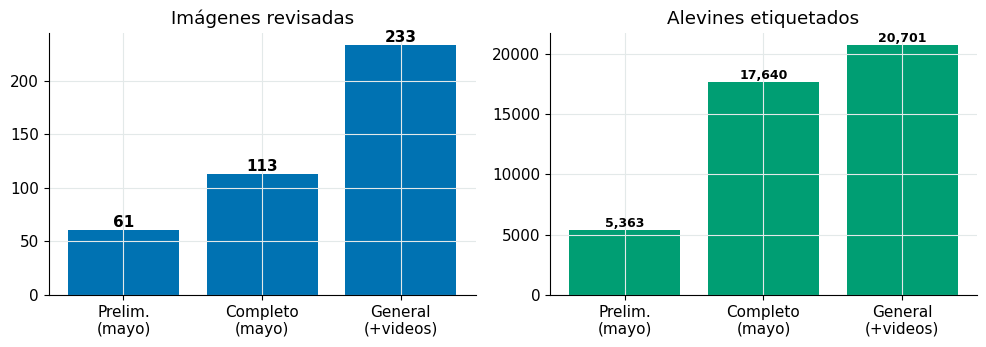

In [3]:
fig, ax = plt.subplots(1,2, figsize=(10,3.6))
et=['Prelim.\n(mayo)','Completo\n(mayo)','General\n(+videos)']
ax[0].bar(et,[61,113,233],color=OK[0]); ax[0].set_title('Imágenes revisadas')
for i,v in enumerate([61,113,233]): ax[0].text(i,v,str(v),ha='center',va='bottom',weight='bold')
ax[1].bar(et,[5363,17640,20701],color=OK[2]); ax[1].set_title('Alevines etiquetados')
for i,v in enumerate([5363,17640,20701]): ax[1].text(i,v,f'{v:,}',ha='center',va='bottom',weight='bold',fontsize=9)
plt.tight_layout(); plt.show()

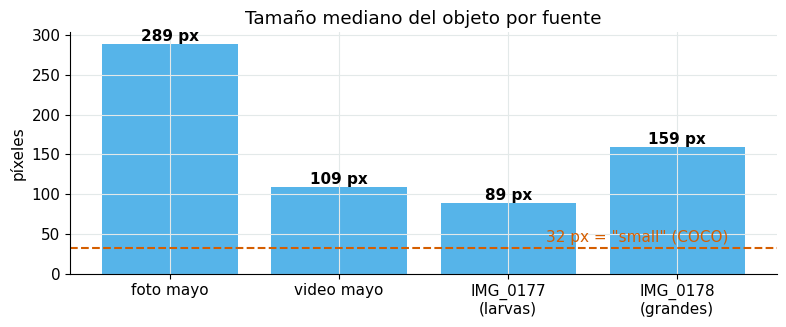

In [4]:
# Tamaño mediano del objeto por fuente (px) — los objetos NO son pequeños
fu=['foto mayo','video mayo','IMG_0177\n(larvas)','IMG_0178\n(grandes)']; tam=[289,109,89,159]
fig,ax=plt.subplots(figsize=(8,3.4))
ax.bar(fu,tam,color=OK[5]); ax.axhline(32,color=OK[3],ls='--')
ax.text(3.3,40,'32 px = "small" (COCO)',color=OK[3],ha='right')
for i,v in enumerate(tam): ax.text(i,v,f'{v} px',ha='center',va='bottom',weight='bold')
ax.set_ylabel('píxeles'); ax.set_title('Tamaño mediano del objeto por fuente'); plt.tight_layout(); plt.show()

## 5. Entrenamiento y ajuste

Transfer learning desde COCO. Se compararon YOLOv8n/s y YOLOv11n/s/m a 960/1280/1536 px.

```bash
# Ejemplo (modelo recomendado). NO se ejecuta aquí (usa GPU, ~30-60 min).
python scripts/train_yolo.py --model yolo11n.pt --data data/dataset_full/data.yaml \
    --epochs 150 --imgsz 1280 --batch 8 --device 0 --name general_v11n_1280 --workers 0
```
Decisiones metodológicas: **calibración del umbral de confianza** para minimizar el error de conteo (no el mAP).

## 6. Evaluación — comparación de modelos (test final, 233 imgs)

In [5]:
g = pd.read_csv(REP/'comparacion_general.csv'); gr = pd.read_csv(REP/'comparacion_grandes.csv')
df = pd.concat([g,gr], ignore_index=True)
nm={'YOLOv11n_general':'v11n@1280','YOLOv11s_general':'v11s@960','YOLOv8n_general':'v8n@960',
    'v11m_1280':'v11m@1280','v11n_1536':'v11n@1536','v11m_1536':'v11m@1536'}
df['nm']=df['modelo'].map(nm).fillna(df['modelo'])
tabla = df[['nm','mAP50','mAP50_95','MAPE','R2','agg_pct']].rename(
    columns={'nm':'Modelo','agg_pct':'Error_lote_%'}).sort_values('mAP50_95',ascending=False)
tabla.round(3)

,Modelo,mAP50,mAP50_95,MAPE,R2,Error_lote_%
5,v11m@1536,0.836,0.506,12.51,0.926,1.53
3,v11m@1280,0.833,0.501,13.57,0.909,6.30
1,v11s@960,0.833,0.498,14.26,0.892,6.88
4,v11n@1536,0.828,0.491,10.57,0.923,2.60
0,v11n@1280,0.825,0.483,12.54,0.936,2.60
2,v8n@960,0.817,0.478,12.09,0.907,7.03


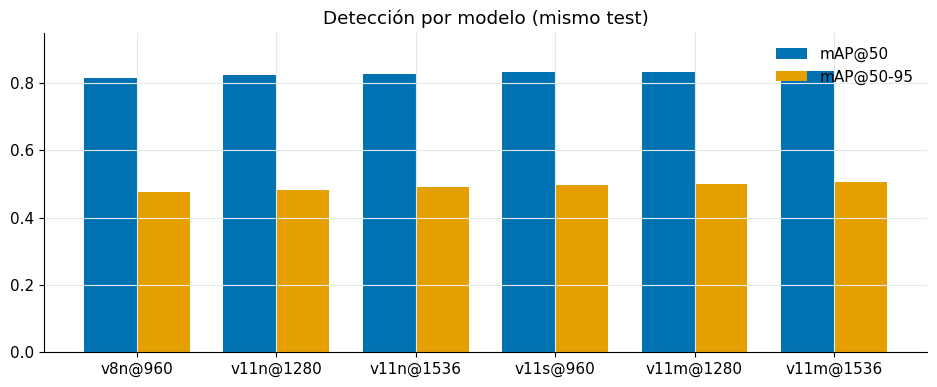

In [6]:
d=df.sort_values('mAP50_95'); x=np.arange(len(d)); w=.38
fig,ax=plt.subplots(figsize=(9.5,4))
ax.bar(x-w/2,d['mAP50'],w,label='mAP@50',color=OK[0])
ax.bar(x+w/2,d['mAP50_95'],w,label='mAP@50-95',color=OK[1])
ax.set_xticks(x); ax.set_xticklabels(d['nm']); ax.set_ylim(0,.95); ax.legend(frameon=False)
ax.set_title('Detección por modelo (mismo test)'); plt.tight_layout(); plt.show()

## 7. Resultado de conteo (modelo final: YOLOv11n@1280)

R² = 0.936  |  MAPE mediana = 8.3%  |  error de lote = 2.6%


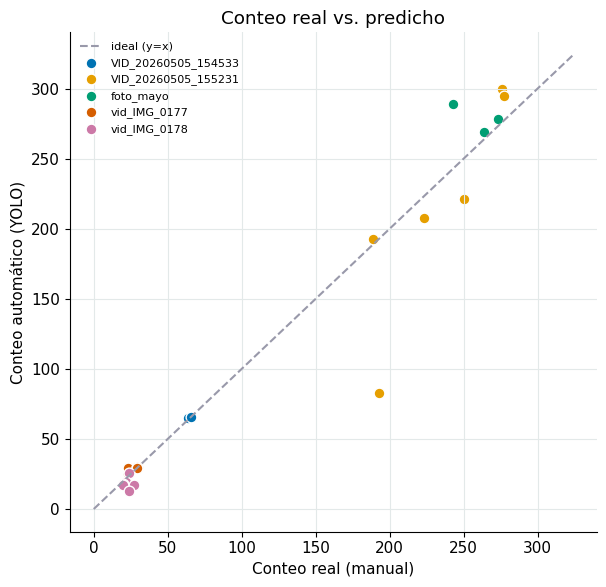

In [7]:
cf = pd.read_csv(CNT/'conteo_final_test.csv')
re, pr = cf['real_count'].values, cf['pred_count'].values
r2 = 1-((pr-re)**2).sum()/((re-re.mean())**2).sum()
lote = abs(pr.sum()-re.sum())/re.sum()*100
print(f'R² = {r2:.3f}  |  MAPE mediana = {np.median(np.abs(pr-re)/np.maximum(re,1)*100):.1f}%  |  error de lote = {lote:.1f}%')

fig,ax=plt.subplots(figsize=(6.2,6))
lim=max(re.max(),pr.max())*1.08
ax.plot([0,lim],[0,lim],'--',color='#99a',label='ideal (y=x)')
for i,s in enumerate(sorted(cf['source'].unique())):
    dd=cf[cf['source']==s]; ax.scatter(dd['real_count'],dd['pred_count'],s=60,color=OK[i%len(OK)],edgecolor='w',label=s)
ax.set_xlabel('Conteo real (manual)'); ax.set_ylabel('Conteo automático (YOLO)')
ax.set_title('Conteo real vs. predicho'); ax.legend(fontsize=8,frameon=False); plt.tight_layout(); plt.show()

## 8. Tracking de video (ByteTrack vs BoT-SORT)

Para contar en video sin duplicar el mismo pez se cuentan **IDs únicos**. Métrica = **fragmentación** (ideal = 1).

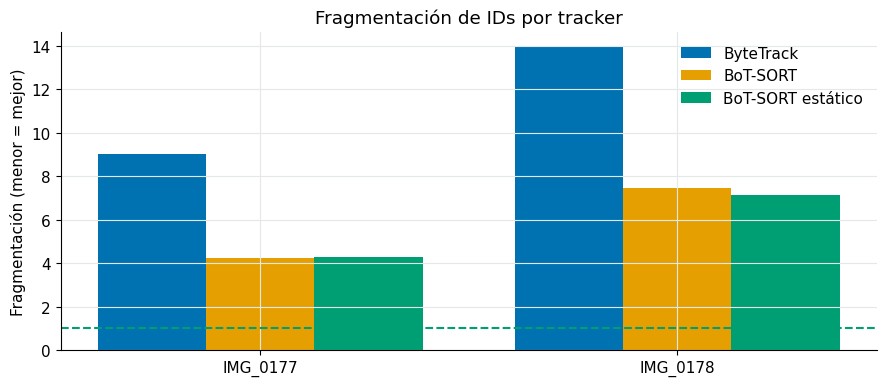

Recomendado: BoT-SORT con gmc_method=none, a frame completo.


In [8]:
tc=pd.read_csv(REP/'trackers_comparacion.csv')
piv=tc.pivot_table(index='video',columns='tracker',values='frag_ratio')
trs=['bytetrack.yaml','botsort.yaml','trackers/botsort_static.yaml']; lb=['ByteTrack','BoT-SORT','BoT-SORT estático']
x=np.arange(len(piv.index)); w=.26
fig,ax=plt.subplots(figsize=(9,4))
for i,(t,l) in enumerate(zip(trs,lb)):
    ax.bar(x+(i-1)*w,[piv.loc[v,t] for v in piv.index],w,label=l,color=OK[i])
ax.axhline(1,color=OK[2],ls='--'); ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel('Fragmentación (menor = mejor)'); ax.legend(frameon=False)
ax.set_title('Fragmentación de IDs por tracker'); plt.tight_layout(); plt.show()
print('Recomendado: BoT-SORT con gmc_method=none, a frame completo.')

## 9. Diagnóstico del techo del mAP@50-95

En el **train** el modelo alcanza 0.62 → las etiquetas soportan >0.60. El limitante es la
**brecha de generalización** (train→test), es decir, **falta de datos diversos**.

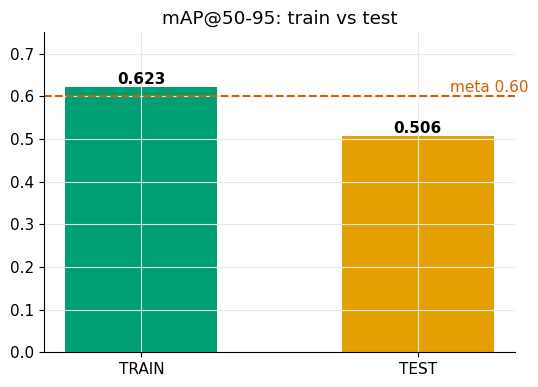

In [9]:
fig,ax=plt.subplots(figsize=(5.5,4))
ax.bar(['TRAIN','TEST'],[0.623,0.506],color=[OK[2],OK[1]],width=.55)
for i,v in enumerate([0.623,0.506]): ax.text(i,v,f'{v:.3f}',ha='center',va='bottom',weight='bold')
ax.axhline(0.60,color=OK[3],ls='--'); ax.text(1.4,.61,'meta 0.60',color=OK[3],ha='right')
ax.set_ylim(0,.75); ax.set_title('mAP@50-95: train vs test'); plt.tight_layout(); plt.show()

## 10. Conclusiones y próximos pasos

**Estado:** sistema funcional de extremo a extremo. Contador **general** validado en 2 sesiones/cámaras
(larvas + peces grandes), sin el falso positivo del recipiente. Error a nivel de **lote: 0.17–2.6%**.

**Próximos pasos (por prioridad):**
1. Más datos diversos (2-3 sesiones nuevas) → cerrar la brecha y superar 0.60 de mAP@50-95.
2. Estación de captura estandarizada (luz difusa + bandeja de una capa).
3. Software de la estación (capturar → contar → mostrar) con mejora incremental.
4. Export móvil (.tflite/.onnx) y medición en el dispositivo.

*Notebook generado automáticamente a partir de los resultados del repositorio.*